1. Tokenization
2. Embeddings (with scaling)
3. Positional Encoding (sinusoidal)
4. Multi-Head Self-Attention (from scratch)
5. Feed-Forward Network
6. Full Encoder Layer (with residuals + LayerNorm)
7. Stack of N Encoder Layers
8. Classification Head (using [CLS] token)
9. Training loop
10. Validation



# Notes

Good sentiment analysis model would have a point (positive or negative) for every word in a sentence (positive points -> positive sentiment, negative points -> negative sentiment of course)

1. Tokenization

In [67]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import load_dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
ds = load_dataset("stanfordnlp/sst2")


def preprocess(example):
    return tokenizer(example["sentence"], truncation=True, max_length=128)

tokenized_ds = ds.map(preprocess, batched=True)
tokenized_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(tokenized_ds["train"], batch_size=32, shuffle=True, collate_fn=data_collator)
val_loader = DataLoader(tokenized_ds["validation"], batch_size=32, collate_fn=data_collator)

1. Embeddings

Transformers (and most NLP models) can't work directly with integer token IDs like 5, 42, 999.We need to convert each discrete token (word or subword) into a dense vector of floating-point numbers that the neural network can process and update during training.


In [68]:
import math
import torch
import torch.nn as nn

class Embeddings(nn.Module):
    def __init__(self, vocab_size: int, d_model: int) -> None:
        super().__init__()

        self.lookup_table = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lookup_table(x) * math.sqrt(self.d_model)



2. Positional encoding

In [69]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len = 5000, dropout = 0.1) -> None:
        super().__init__()

        self.dropout = nn.Dropout(p = dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))

        # Apply sine to even indices (0, 2, 4, ...)
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # Apply cosine to odd indices (1, 3, 5, ...)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)
        print("PE", position, position.shape)

    def forward(self, x): 
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

PE tensor([[   0],
        [   1],
        [   2],
        ...,
        [4997],
        [4998],
        [4999]]) torch.Size([5000, 1])


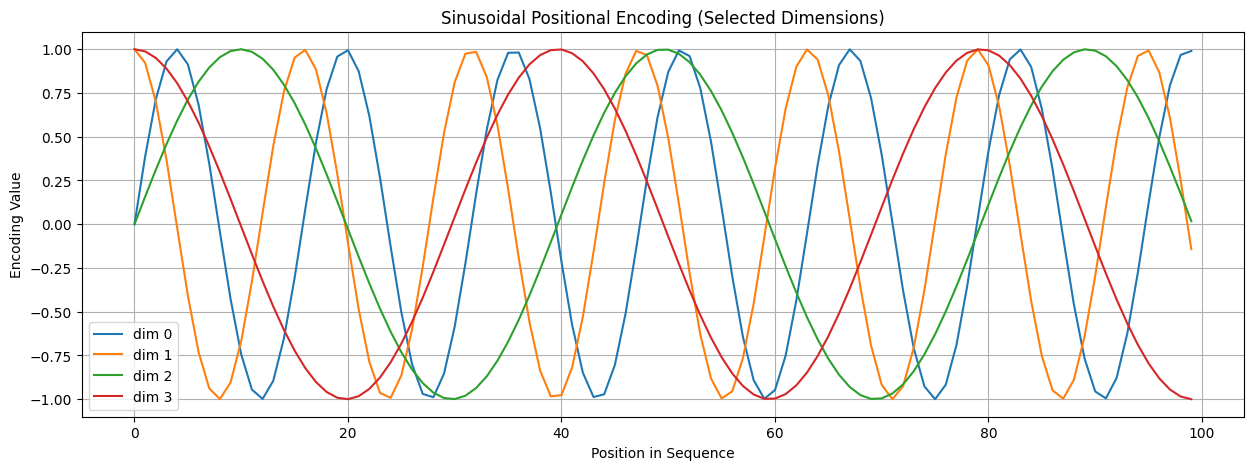

In [70]:
pe = PositionalEncoding(20, dropout=0)  # dropout=0 so we see pure signal

# Input: batch of 1, sequence length 100, d_model=20
y = pe(torch.zeros(1, 100, 20))  # call directly: pe(...) instead of pe.forward(...)

# Plot dimensions 4 to 7 across 100 positions
plt.figure(figsize=(15, 5))
plt.plot(np.arange(100), y[0, :, 2:6].detach().cpu().numpy())
plt.legend(["dim %d" % p for p in range(4)])
plt.title("Sinusoidal Positional Encoding (Selected Dimensions)")
plt.xlabel("Position in Sequence")
plt.ylabel("Encoding Value")
plt.grid(True)
plt.show()

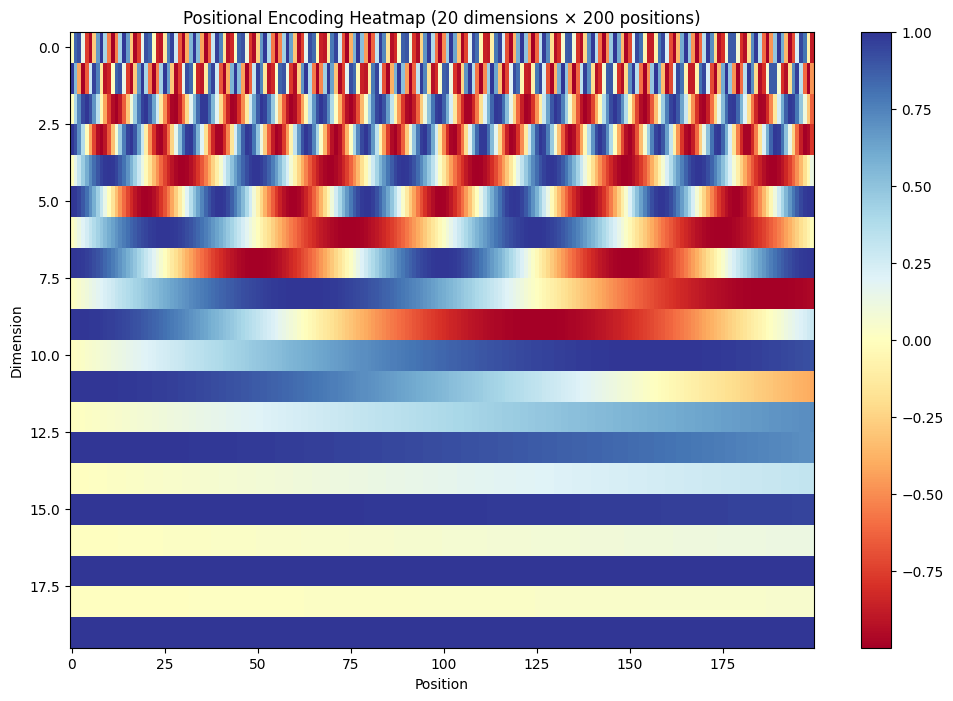

In [71]:
y_full = pe(torch.zeros(1, 200, 20))  # longer sequence for better view

plt.figure(figsize=(12, 8))
plt.imshow(y_full[0].detach().cpu().numpy().T, cmap='RdYlBu', aspect='auto')
plt.title("Positional Encoding Heatmap (20 dimensions × 200 positions)")
plt.xlabel("Position")
plt.ylabel("Dimension")
plt.colorbar()
plt.show()

4. Attention

In [ ]:
# TODO

8. Training loop (for now it's only for testing/validating)



In [72]:
def training_loop():
    # HYPERPARAMETERS (for testing for NOW1!!!1)
    # just mess below
    d_model = 256
    batch = next(iter(train_loader))
    input_ids = batch["input_ids"][0]
    mask = batch['attention_mask'][0]
    actual_len = mask.sum().item()
    print("Token ids", actual_len)
    # this way we won't get <PAD>
    text = tokenizer.decode(input_ids[:actual_len])
    vocab_size = tokenizer.vocab_size

    print("Current text", text)
    print("Unsqueeze the fuck", input_ids.shape, input_ids.unsqueeze(0).shape)
    embeddings_layer = Embeddings(vocab_size, d_model)

    with torch.no_grad():
        embedded = embeddings_layer(input_ids.unsqueeze(0))
        print("\nEmbedded shape:", embedded.shape)  # Should be (1, seq_len, 256)

        pos_encoding = PositionalEncoding(d_model=d_model, max_len = 128, dropout=0.0)
        embedded_with_pos = pos_encoding(embedded)
        print("After PE shape:", embedded_with_pos.shape)



training_loop()

Token ids 17
Current text [CLS] so overwhelmed by its lack of purpose that it seeks excitement in manufactured high drama [SEP]
Unsqueeze the fuck torch.Size([47]) torch.Size([1, 47])

Embedded shape: torch.Size([1, 47, 256])
PE tensor([[  0],
        [  1],
        [  2],
        [  3],
        [  4],
        [  5],
        [  6],
        [  7],
        [  8],
        [  9],
        [ 10],
        [ 11],
        [ 12],
        [ 13],
        [ 14],
        [ 15],
        [ 16],
        [ 17],
        [ 18],
        [ 19],
        [ 20],
        [ 21],
        [ 22],
        [ 23],
        [ 24],
        [ 25],
        [ 26],
        [ 27],
        [ 28],
        [ 29],
        [ 30],
        [ 31],
        [ 32],
        [ 33],
        [ 34],
        [ 35],
        [ 36],
        [ 37],
        [ 38],
        [ 39],
        [ 40],
        [ 41],
        [ 42],
        [ 43],
        [ 44],
        [ 45],
        [ 46],
        [ 47],
        [ 48],
        [ 49],
        [ 50],
      